In [72]:
import numpy as np
from scipy.stats import chi2
from scipy.special import gammaln, gamma
from scipy.integrate import quad
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,                # Usa o motor LaTeX para escrever tudo
    "font.family": "serif",             # Usa fonte serifada
    "font.serif": ["Palatino"],         # Especifica a fonte padrão do LaTeX
    "axes.labelsize": 14,               # Tamanho dos rótulos (H0, Wm)
    "font.size": 14,                    # Tamanho geral
    "legend.fontsize": 12,              # Tamanho da legenda
    #"xtick.labelsize": 12,              # Tamanho dos números no eixo X
    #"ytick.labelsize": 12,              # Tamanho dos números no eixo Y
})

def analise_chi2v(par, chimin, ndata, axis, dist_log, hv_norm, nome=0):

    if dist_log:
        def chiDist(chi, n):
            log_pdf = (n / 2) * np.log(n) + ((n - 2) / 2) * np.log(chi) - (n / 2) * chi - (n / 2) * np.log(2) - gammaln(n / 2)
            return np.exp(log_pdf)
    else:
        def chiDist(chi, n):
            return (n**(n/2)*((chi)**((n-2)/2))*np.exp(-(n/2)*chi))/(2**(n/2)*gamma(n/2))

    def chiCDF(x, n):
        res = np.zeros_like(x)
        for i, val in enumerate(x):
            y, err = quad(chiDist, 0, val, args=(n))
            res[i]=y
        return res
    
    par1, par2 = par
    chimin1, chimin2 = chimin
    xlim, ylim = axis
        
    v1 = ndata - len(par1)
    v2 = ndata - len(par2)

    chi = np.linspace(0, xlim, 500)
    chiv1 = np.full((500), 0.472)#chimin1/v1)
    chiv2 = np.full((500), 0.490)#chimin2/v2)

    hv1 = chiDist(chi, v1)
    hv2 = chiDist(chi, v2)

    cdf1 = chiCDF(chi, v1)
    cdf2 = chiCDF(chi, v2)

    y = np.linspace(0, ylim, 500)

    moda1 = 1 - 2/v1
    moda2 = 1 - 2/v2

    perc1 = chi2.cdf(chimin1, v1)
    perc2 = chi2.cdf(chimin2, v2)

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    if hv_norm:
        ax1.plot(chi, hv1/np.max(hv1), label=r'$h_{\nu}$')
        ax2.plot(chi, hv2/np.max(hv2), label=r'$h_{\nu}$')
    else:
        ax1.plot(chi, hv1, label=r'$h_{\nu}$')
        ax2.plot(chi, hv2, label=r'$h_{\nu}$')

    ax1.plot(chi, cdf1, label='CDF')
    ax2.plot(chi, cdf2, label='CDF')

    ax1.plot(np.full((500), moda1), y, '--', label=r'$(\chi ^{2} _{\nu})_{\mathrm{mp}}$' + '$= {0}$'.format(np.round(moda1, 3)))
    ax2.plot(np.full((500), moda2), y, '--', label=r'$(\chi ^{2} _{\nu})_{\mathrm{mp}}$' + '$= {0}$'.format(np.round(moda2, 3)))

    ax1.plot(chiv1, y, '--', label=r"$\chi _{\nu} ^{2}$" + "$= {0}$".format(0.472))#np.round(chimin1/v1, 3)))
    ax2.plot(chiv2, y, '--', label=r"$\chi _{\nu} ^{2}$" + "$= {0}$".format(0.490))#np.round(chimin2/v2, 3)))

    ax1.set_title(r'$\Lambda$CDM plano')#'Sem correção')
    ax1.set_xticks(np.arange(0, xlim+0.01, 0.5))
    ax1.set_yticks(np.arange(0, ylim+0.01, 0.5))
    ax1.axis((0, xlim, 0, ylim))
    ax1.grid(linestyle='-.', linewidth='0.5')
    ax1.set_ylabel(r'$h_{\nu}$')
    ax1.set_xlabel(r'$\chi _{\nu} ^{2}$')
    ax1.legend(loc='best')

    ax2.set_title(r'O$\Lambda$CDM')#'Com correção')
    ax2.set_xticks(np.arange(0, xlim+0.01, 0.5))
    ax2.set_yticks(np.arange(0, ylim+0.01, 0.5))
    ax2.axis((0, xlim, 0, ylim))
    ax2.grid(linestyle='-.', linewidth='0.5')
    ax2.set_ylabel(r'$h_{\nu}$')
    ax2.set_xlabel(r'$\chi _{\nu} ^{2}$')
    ax2.legend(loc='best')

    if not nome == 0:
        plt.savefig('fig/'+nome+'.pdf', bbox_inches='tight')

    plt.tight_layout()
    plt.show()

    print('Plano:')
    print(f'Probabilidade = {np.round(perc1*100, 2)}%')
    print(f'chi2v = {chimin1/v1}')
    print(f'chi2v mais provável = {moda1}')

    print('\nO:')
    print(f'Probabilidade = {np.round(perc2*100, 2)}%')
    print(f'chi2v = {chimin1/v2}')
    print(f'chi2v mais provável = {moda2}')

In [10]:
resultados = {
    'FLCDM': {
        'CC': {
            'f': {},
            'no-f': {}
        }
    },

    'OLCDM': {
        'CC': {
            'f': {'par': [66.40099, 0.36888, 0.67902], 'chimin': },
            'no-f': {}
        },

        'Pantheon': {
            'f': {'par': [74.83018, 0.34477, 0.82289, 0.83978], 'chimin': 1043.2854476235807},
            'no-f': {'par': [75.37823, 0.34411, 0.81955], 'chimin': 735.7643695995212},
            'ndata': 1048
        }
    }
}

/tmp/ipykernel_21686/4176300916.py:22: RuntimeWarning: divide by zero encountered in log
  log_pdf = (n / 2) * np.log(n) + ((n - 2) / 2) * np.log(chi) - (n / 2) * chi - (n / 2) * np.log(2) - gammaln(n / 2)


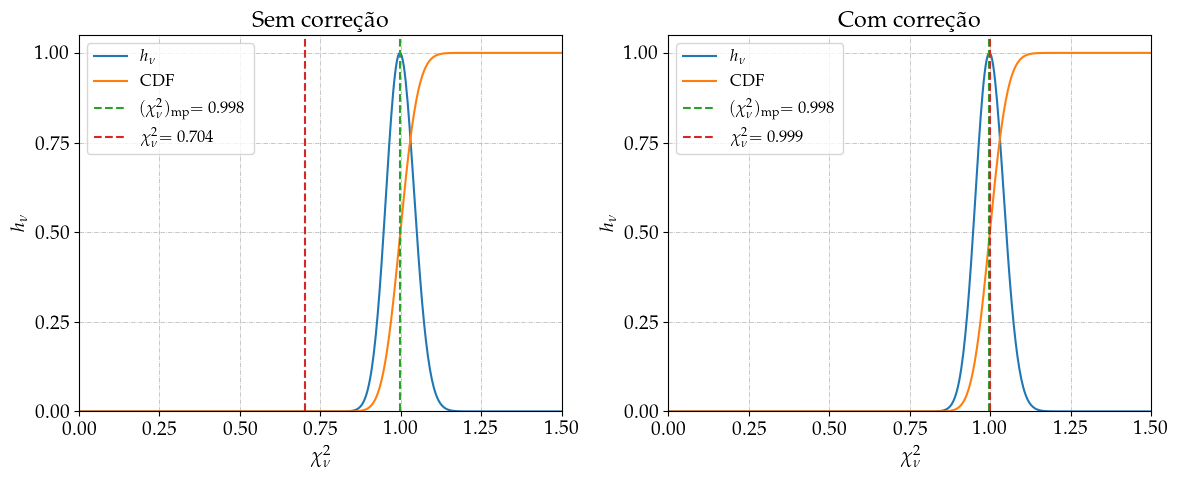

Plano:
Probabilidade = 0.0%
chi2v = 0.7040807364588719
chi2v mais provável = 0.9980861244019139

O:
Probabilidade = 49.96%
chi2v = 0.7047551432945605
chi2v mais provável = 0.9980842911877394


In [70]:
resultado = resultados['OLCDM']['Pantheon']

par1 = resultado['no-f']['par']
par2 = resultado['f']['par']

chimin1 = resultado['no-f']['chimin']
chimin2 = resultado['f']['chimin']

ndata = resultado['ndata']

analise_chi2v((par1, par2), (chimin1, chimin2), ndata, (1.50, 1.05), dist_log=True, hv_norm=True, nome='pantheon-chi2')

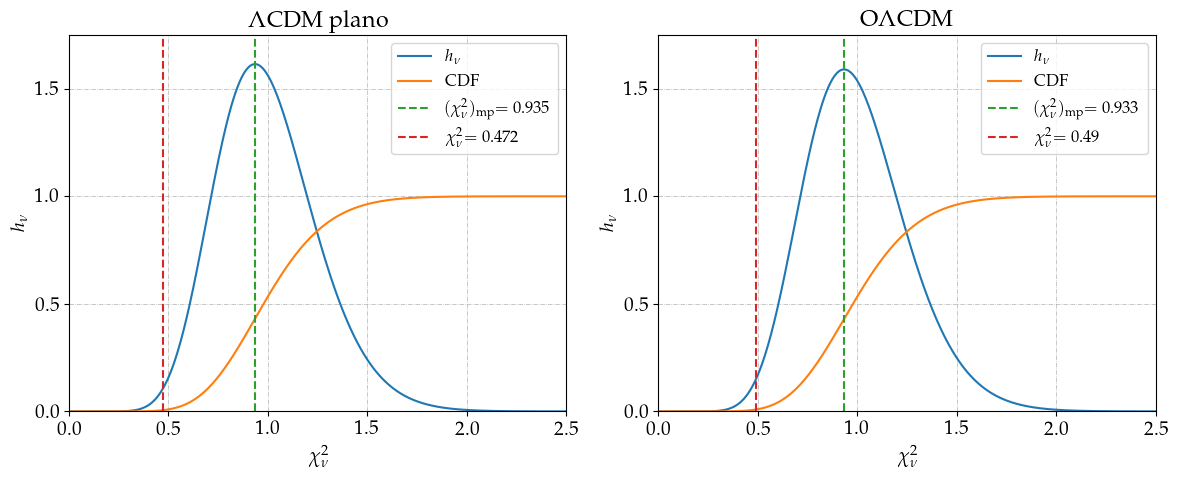

Plano:
Probabilidade = 0.0%
chi2v = 0.16129032258064516
chi2v mais provável = 0.935483870967742

O:
Probabilidade = 0.0%
chi2v = 0.16666666666666666
chi2v mais provável = 0.9333333333333333


In [73]:
analise_chi2v(([66.7, 0.34], [66.5, 0.37, 0.69]), (5, 3), 33, (2.50, 1.75), dist_log=False, hv_norm=False, nome='chi2-no_f')